# PROCESSAMENTO DE LINGUAGEM NATURAL
Representações vetoriais




INTRODUÇÃO


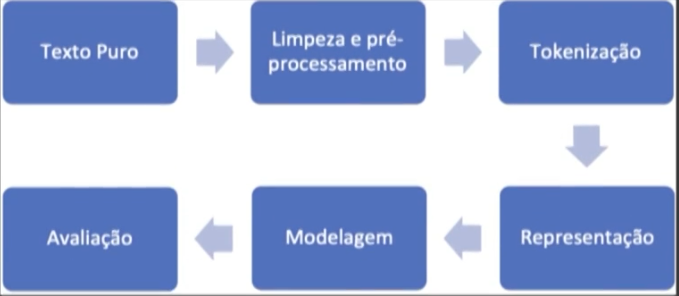

Passo 1. Carregar o corpus

In [ ]:
poema = """E agora, José?
A festa acabou,
a luz apagou,
o povo sumiu,
a noite esfriou,
 e agora, José?
 e agora, você?
 você que é sem nome,
 que zomba dos outros,
 você que faz versos,
 que ama, protesta?
 e agora, José?

 Está sem mulher,
 está sem discurso,
 está sem carinho,
 já não pode beber,
 já não pode fumar,
 cuspir já não pode,
 a noite esfriou,
 o dia não veio,
 o bonde não veio,
 o riso não veio,
 não veio a utopia
 e tudo acabou
 e tudo fugiu
 e tudo mofou,
 e agora, José?

 E agora, José?
 Sua doce palavra,
 seu instante de febre,
 sua gula e jejum,
 sua biblioteca,
 sua lavra de ouro,
 seu terno de vidro,
 sua incoerência,
 seu ódio — e agora?

 Com a chave na mão
 quer abrir a porta,
 não existe porta;
 quer morrer no mar,
 mas o mar secou;
 quer ir para Minas,
 Minas não há mais.
 José, e agora?

 Se você gritasse,
 se você gemesse,
 se você tocasse,
 a valsa vienense,
 se você dormisse,
 se você cansasse,
 se você morresse...

 Mas você não morre,
 você é duro, José!

 Sozinho no escuro
 qual bicho do mato,
 sem teogonia,
 sem parede nua
 para se encostar,
 sem cavalo preto
 que fuja a galope,
 você marcha, José!
 José, para onde?"""

Passo 2. Tokenizando o corpus

In [ ]:
import nltk
from nltk import tokenize

nltk.download('punkt') #para baizar o tokenizador


Armazenando as sentenças

In [ ]:
poema = poema.lower().split("\n")
poema

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


In [ ]:
texto_tok = []

for verso in poema:
    tokens = tokenize.word_tokenize(verso, language="portuguese")
    texto_tok.append(tokens)

texto_tok


Passo 3. Inserindo os marcadores de inico e fim de sentença

Usando o metodo do NLTKque se chama pad_both_ends

Bigramas

In [ ]:
from nltk .lm.preprocessing import pad_both_ends

ngramas = 2

texto_tok_pad = []

for verso in texto_tok:
  padded = list(pad_both_ends(verso, n=ngramas))
  texto_tok_pad.append(padded)

  texto_tok_pad

Passo 4. Calculando os n-gramas

Uasanod o modelo NLTK  que se chama nltk.ngrama

In [ ]:
from collections import Counter

n = 3
texto_tok_tuple = [tuple(p) for p in texto_tok]

frequencia = Counter(texto_tok_tuple)

print(f"Top 5 {n}-gramas mais comuns:")
for gram, freq in frequencia.most_common(5):
    print(f"{' '.join(gram)}: {freq}")

print(f"\nTotal de {n}-gramas: {len(texto_tok_tuple)}")

Passo 5. Colocar todos os tokens na lista



In [ ]:
from nltk.util import ngrams

bigrams = list(ngrams(texto_tok_tuple, 2))
contagem_bigrams = Counter(bigrams)

Passo 6. definindo o vocabulario

In [ ]:
vocabulario = sorted(set(texto_tok_tuple))
print("\nTamanho do vocabulário:", len(vocabulario))

Passo 7. Treinando um modelo de linguagem

In [ ]:
import random

modelo_bigram = {}
for (w1, w2) in bigrams:
    if isinstance(w1, (tuple, list)):
        w1 = "_".join(w1)
    if isinstance(w2, (tuple, list)):
        w2 = "_".join(w2)

    if w1 not in modelo_bigram:
        modelo_bigram[w1] = []
    modelo_bigram[w1].append(w2)

def gerar_texto(modelo, tamanho=15, palavra_inicial=None):
    if palavra_inicial is None:
        palavra_inicial = random.choice(list(modelo.keys()))
    resultado = [palavra_inicial]
    for _ in range(tamanho - 1):
        ultima = resultado[-1]
        if ultima not in modelo:
            break
        proxima = random.choice(modelo[ultima])
        resultado.append(proxima)
    return " ".join(resultado)

print("\nTexto gerado pelo modelo:")
print(gerar_texto(modelo_bigram, tamanho=1))

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
import nltk
import numpy as np

nltk.download('stopwords')
if isinstance(texto_tok_tuple[0], (tuple, list)):
    texto_tok_tuple = ["_".join(t) for t in texto_tok_tuple]

texto = " ".join(texto_tok_tuple)
stop_words_pt = stopwords.words('portuguese')
vectorizer = CountVectorizer(stop_words=stop_words_pt)
X = vectorizer.fit_transform([texto])
lda = LatentDirichletAllocation(
    n_components=3,
    random_state=42,
    learning_method='online'
)

lda.fit(X)

termos = np.array(vectorizer.get_feature_names_out())
n_top_words = 10
for idx, componente in enumerate(lda.components_):
    termos_topicos = termos[componente.argsort()[:-n_top_words - 1:-1]]
    print(f"\nTópico {idx + 1}:")
    print(", ".join(termos_topicos))
